# Unemployment in India: exploratory analysis

This notebook explores monthly unemployment estimates in the Kaggle **Unemployment in India** dataset, with particular attention to regional variation and the period beginning in March 2020. It is descriptive analysis, not a causal estimate of the pandemic's effect.

**Source:** [Unemployment in India — Kaggle](https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india). The downloaded archive is stored in `data/`; the main file used here is `Unemployment in India.csv`.

**Scope and limitations:** the main file reports state/region and rural/urban observations at a monthly frequency. State-level values below are unweighted averages of available area observations; they are not population-weighted state estimates. The dataset is a short observational series and its estimates, coverage, and definitions should be checked against the original publisher before policy use. Correlation does not establish causation. A second CSV in the archive has a different schema and overlapping dates, so it is not appended to the main file.

## 1. Imports and data location

The path lookup supports running the notebook with either the project directory or this notebook's directory as the working directory.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 110

data_candidates = [Path.cwd() / "data", Path.cwd().parent / "data"]
data_dir = next((path for path in data_candidates if path.is_dir()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find the data/ folder. Run this notebook from the DATA SCIENCE "
        "project directory, which should contain data/Unemployment in India.csv."
    )

data_path = data_dir / "Unemployment in India.csv"
if not data_path.is_file():
    raise FileNotFoundError(f"Expected dataset file was not found: {data_path}")
print(f"Using dataset: {data_path.resolve()}")

Using dataset: C:\Users\Sreeyakeshrajan_T\OneDrive\Desktop\OIBSIP\DATA SCIENCE\data\Unemployment in India.csv


## 2. Load and inspect the raw data

Inspect shape, field names, types, sample rows, and missing values before making cleaning decisions.

In [2]:
raw = pd.read_csv(data_path)
print(f"Rows: {raw.shape[0]:,} | Columns: {raw.shape[1]}")
display(raw.head())
print("Raw column names:")
print(raw.columns.tolist())
print("\nRaw data types:")
display(raw.dtypes.rename("dtype").to_frame())
print("\nMissing values by column:")
display(raw.isna().sum().rename("missing_count").to_frame())

Rows: 768 | Columns: 7


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


Raw column names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Raw data types:


,dtype
Region,str
Date,str
Frequency,str
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,str



Missing values by column:


,missing_count
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


## 3. Clean fields and validate records

The source includes whitespace in some headers and text values, and its dates use day-month-year notation. We normalize those fields, convert measurements to numeric values, and report invalid or duplicate records. Rows are removed only where the date, region, or unemployment rate needed for the core analysis is unusable.

In [3]:
df = raw.copy()
df.columns = df.columns.str.strip()

for column in ["Region", "Frequency", "Area"]:
    if column in df.columns:
        df[column] = df[column].astype("string").str.strip()

df["Date"] = pd.to_datetime(df["Date"].astype("string").str.strip(), format="%d-%m-%Y", errors="coerce")
measurement_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)",
]
for column in measurement_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

exact_duplicates = int(df.duplicated().sum())
invalid_dates = int(df["Date"].isna().sum())
missing_core = int(df[["Region", "Estimated Unemployment Rate (%)"]].isna().any(axis=1).sum())
print(f"Exact duplicate rows before removal: {exact_duplicates}")
print(f"Unparseable/missing dates: {invalid_dates}")
print(f"Rows missing region or unemployment rate: {missing_core}")

df = df.drop_duplicates()
df = df.dropna(subset=["Date", "Region", "Estimated Unemployment Rate (%)"])
df = df.sort_values(["Date", "Region", "Area"], na_position="last").reset_index(drop=True)

print(f"\nAnalysis rows after cleaning: {len(df):,}")
print(f"Date range: {df['Date'].min():%d %b %Y} to {df['Date'].max():%d %b %Y}")
print(f"Regions: {df['Region'].nunique()} | Areas: {df['Area'].nunique() if 'Area' in df else 'not available'}")
print("\nCleaned data types:")
display(df.dtypes.rename("dtype").to_frame())
print("\nRemaining missing values:")
display(df.isna().sum().rename("missing_count").to_frame())
print("\nFrequency counts:")
display(df["Frequency"].value_counts(dropna=False).rename_axis("frequency").to_frame("rows"))

Exact duplicate rows before removal: 27
Unparseable/missing dates: 28
Rows missing region or unemployment rate: 28

Analysis rows after cleaning: 740
Date range: 31 May 2019 to 30 Jun 2020
Regions: 28 | Areas: 2

Cleaned data types:


,dtype
Region,string
Date,datetime64[us]
Frequency,string
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,string



Remaining missing values:


,missing_count
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0



Frequency counts:


,rows
frequency,
Monthly,740


## 4. Coverage and summary statistics

The following tables establish the observed time span and the spread of the supplied measures. An observation is a reported region-area record for one date; these are not independent individuals.

In [4]:
coverage = pd.Series(
    {
        "first_date": df["Date"].min(),
        "last_date": df["Date"].max(),
        "unique_months": df["Date"].dt.to_period("M").nunique(),
        "regions": df["Region"].nunique(),
        "area_categories": df["Area"].nunique() if "Area" in df else 0,
    },
    name="value",
)
display(coverage.to_frame())
display(df[measurement_columns].describe().T.round(2))

,value
first_date,2019-05-31 00:00:00
last_date,2020-06-30 00:00:00
unique_months,14
regions,28
area_categories,2


,count,mean,std,min,25%,50%,75%,max
Estimated Unemployment Rate (%),740.0,11.79,10.72,0.00,4.66,8.35,15.89,76.74
Estimated Employed,740.0,7204460.03,8087988.43,49420.00,1190404.50,4744178.50,11275489.50,45777509.00
Estimated Labour Participation Rate (%),740.0,42.63,8.11,13.33,38.06,41.16,45.50,72.57


## 5. Region-wise average unemployment

Each region's plotted mean averages its available monthly rural/urban reports equally. Differences in coverage and the lack of population weights mean the ranking should be treated as a descriptive comparison of dataset rows, not a definitive ranking of residents' unemployment exposure.

,mean_unemployment_rate_pct
Region,
Tripura,28.35
Haryana,26.28
Jharkhand,20.58
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Jammu & Kashmir,16.19
Chandigarh,15.99
Rajasthan,14.06


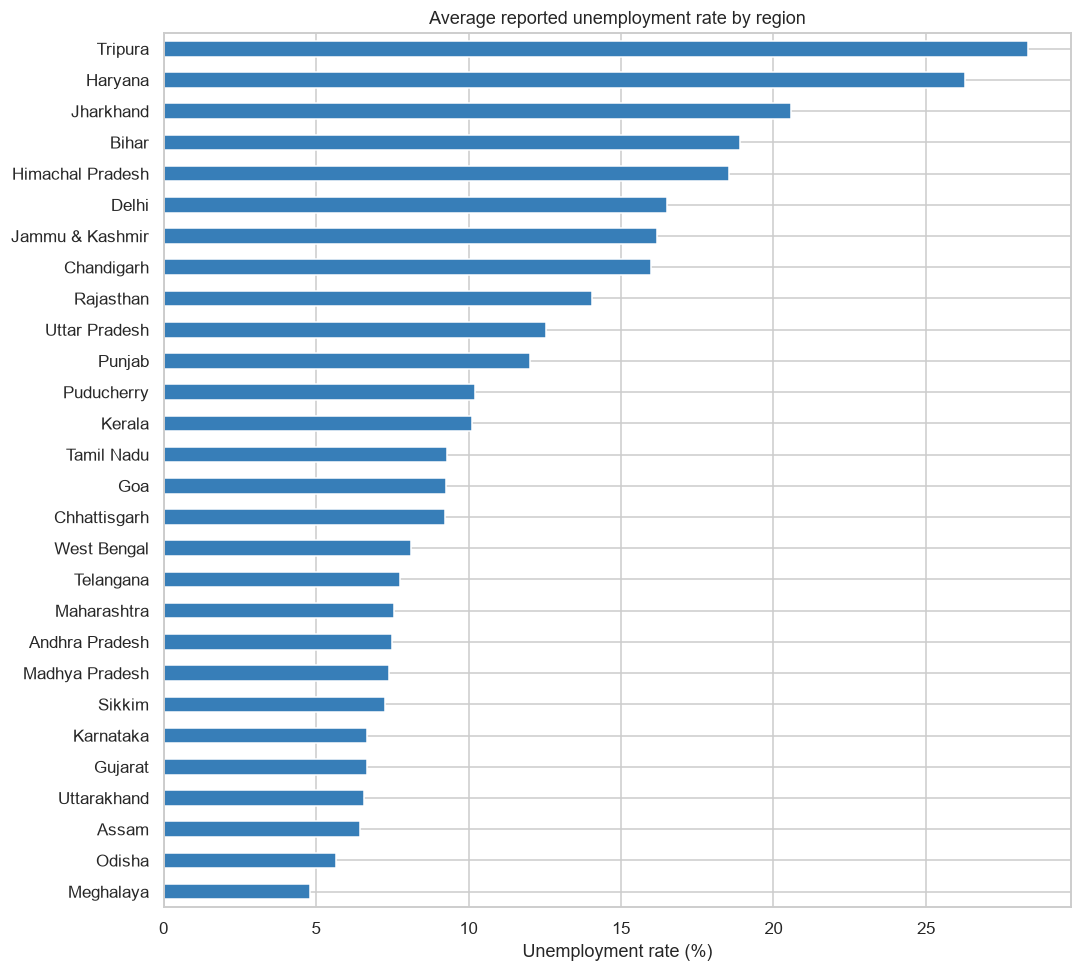

In [5]:
region_means = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)
display(region_means.rename("mean_unemployment_rate_pct").to_frame().round(2))

ax = region_means.sort_values().plot(kind="barh", color="#377eb8", figsize=(10, 9))
ax.set(title="Average reported unemployment rate by region", xlabel="Unemployment rate (%)", ylabel="")
plt.tight_layout()
plt.show()

**How to read this chart:** the longest bars identify regions with the highest mean across their reported records. Because the calculation gives each available area-month row equal weight, it is not a population-weighted annual or state-level unemployment rate.

## 6. Monthly unemployment trend

To avoid giving states with more reported area records extra influence, first average within each region-month, then average those regional values for each month.

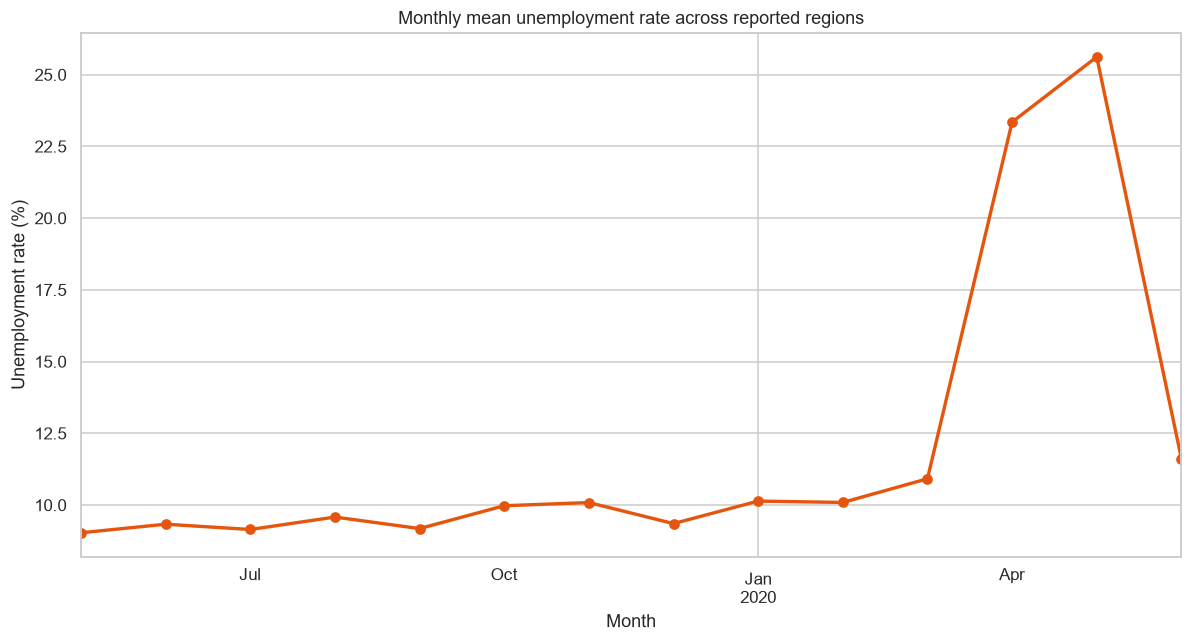

,mean_unemployment_rate_pct
Date,
2019-05-31,9.03
2019-06-30,9.33
2019-07-31,9.15
2019-08-31,9.58
2019-09-30,9.18
2019-10-31,9.97
2019-11-30,10.09
2019-12-31,9.35
2020-01-31,10.14


In [6]:
region_month = (
    df.groupby(["Region", "Date"], as_index=False)["Estimated Unemployment Rate (%)"]
    .mean()
)
monthly_mean = region_month.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

ax = monthly_mean.plot(marker="o", linewidth=2.2, color="#e6550d")
ax.set(title="Monthly mean unemployment rate across reported regions", xlabel="Month", ylabel="Unemployment rate (%)")
plt.tight_layout()
plt.show()
display(monthly_mean.rename("mean_unemployment_rate_pct").to_frame().round(2))

**Observation prompt:** note the months with visible peaks or troughs, and compare their timing with the period boundary used later. These are movements in the dataset's regional estimates; this line alone cannot attribute changes to a particular cause.

## 7. Time series for selected states

The chart uses a small set of familiar states when present in the file. Area observations are averaged within state-month before plotting. If a preferred state is absent, the notebook selects available regions with the most observations and reports the actual selection.

Regions shown: Maharashtra, Andhra Pradesh, Tamil Nadu, Delhi


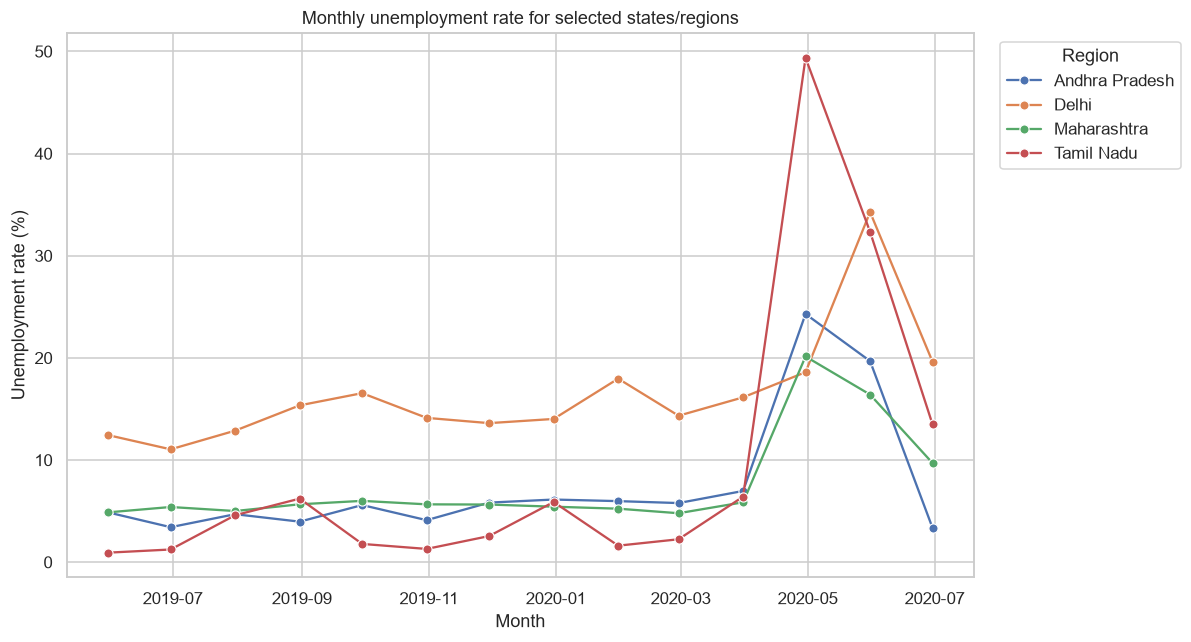

In [7]:
preferred_regions = ["Maharashtra", "Andhra Pradesh", "Tamil Nadu", "Delhi"]
available_preferred = [name for name in preferred_regions if name in set(df["Region"])]
if len(available_preferred) >= 3:
    selected_regions = available_preferred[:4]
else:
    most_observed = df["Region"].value_counts().index.tolist()
    selected_regions = list(dict.fromkeys(available_preferred + [name for name in most_observed if name not in available_preferred]))[:4]

print("Regions shown:", ", ".join(selected_regions))
state_month = (
    df[df["Region"].isin(selected_regions)]
    .groupby(["Date", "Region"], as_index=False)["Estimated Unemployment Rate (%)"]
    .mean()
)
ax = sns.lineplot(data=state_month, x="Date", y="Estimated Unemployment Rate (%)", hue="Region", marker="o")
ax.set(title="Monthly unemployment rate for selected states/regions", xlabel="Month", ylabel="Unemployment rate (%)")
ax.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Observation prompt:** compare the scale and timing of the visible state-level movements. The selected lines are a subset for readability; they should not be interpreted as representing every region.

## 8. Ten regions with highest average rate

This ranking uses the same unweighted region mean as Section 5. Values are rounded for display only.

,mean_unemployment_rate_pct
Region,
Tripura,28.35
Haryana,26.28
Jharkhand,20.58
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Jammu & Kashmir,16.19
Chandigarh,15.99
Rajasthan,14.06


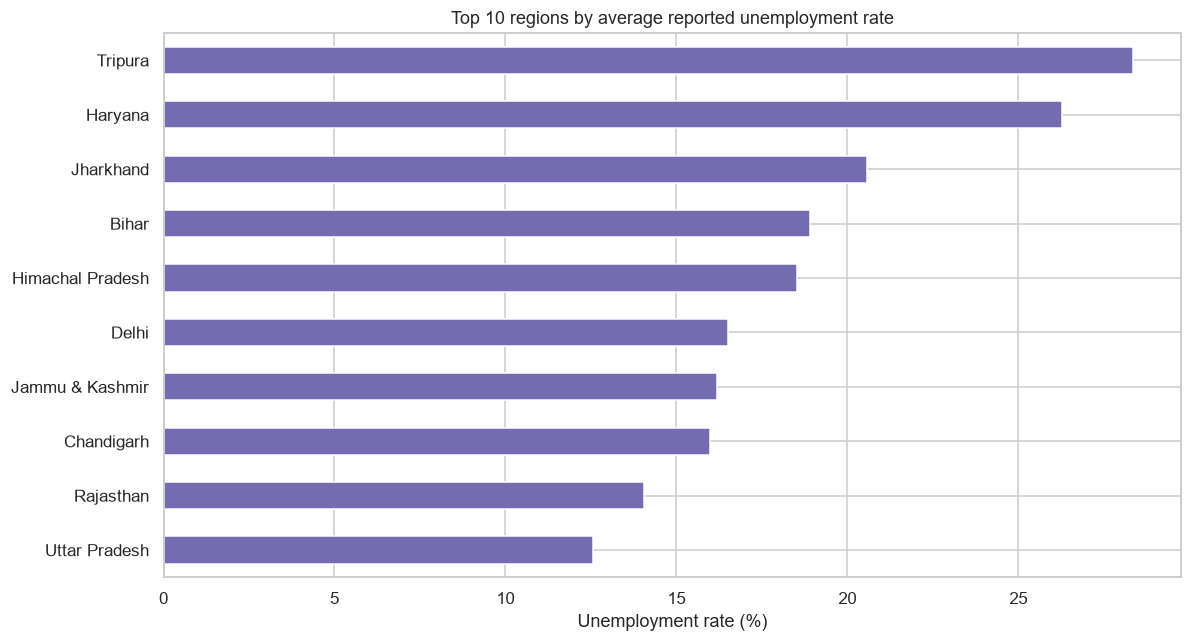

In [8]:
top10 = region_means.head(10).sort_values()
display(region_means.head(10).rename("mean_unemployment_rate_pct").to_frame().round(2))
ax = top10.plot(kind="barh", color="#756bb1")
ax.set(title="Top 10 regions by average reported unemployment rate", xlabel="Unemployment rate (%)", ylabel="")
plt.tight_layout()
plt.show()

**Observation prompt:** the table and bars show which region means are largest in this sample. The ranking is sensitive to the observation window, area coverage, and weighting choice.

## 9. Rural and urban comparison

This optional view keeps the source's `Area` distinction rather than silently mixing it into state means. It is shown only when the column has usable values.

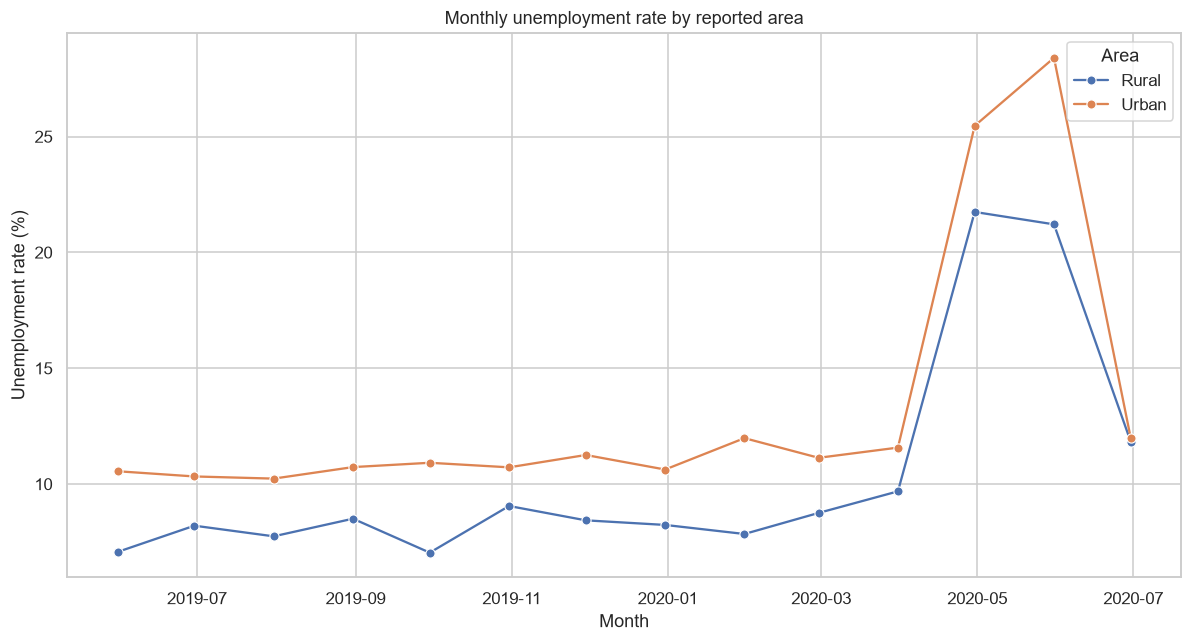

,count,mean,median
Area,,,
Rural,359,10.32,6.76
Urban,381,13.17,9.97


In [9]:
if "Area" in df.columns and df["Area"].notna().any():
    area_month = df.groupby(["Date", "Area"], as_index=False)["Estimated Unemployment Rate (%)"].mean()
    ax = sns.lineplot(data=area_month, x="Date", y="Estimated Unemployment Rate (%)", hue="Area", marker="o")
    ax.set(title="Monthly unemployment rate by reported area", xlabel="Month", ylabel="Unemployment rate (%)")
    plt.tight_layout()
    plt.show()
    display(df.groupby("Area")["Estimated Unemployment Rate (%)"].agg(["count", "mean", "median"]).round(2))
else:
    print("No usable Area field was present; area comparison skipped.")

## 10. Correlation between the supplied measures

The heatmap uses pairwise-complete rows for unemployment rate, estimated employed, and labour participation rate. Employment is an absolute estimate and can co-vary with population size; the correlations are descriptive associations, not causal effects.

Rows used for pairwise correlation: 740


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000,-0.223,0.003
Estimated Employed,-0.223,1.000,0.011
Estimated Labour Participation Rate (%),0.003,0.011,1.000


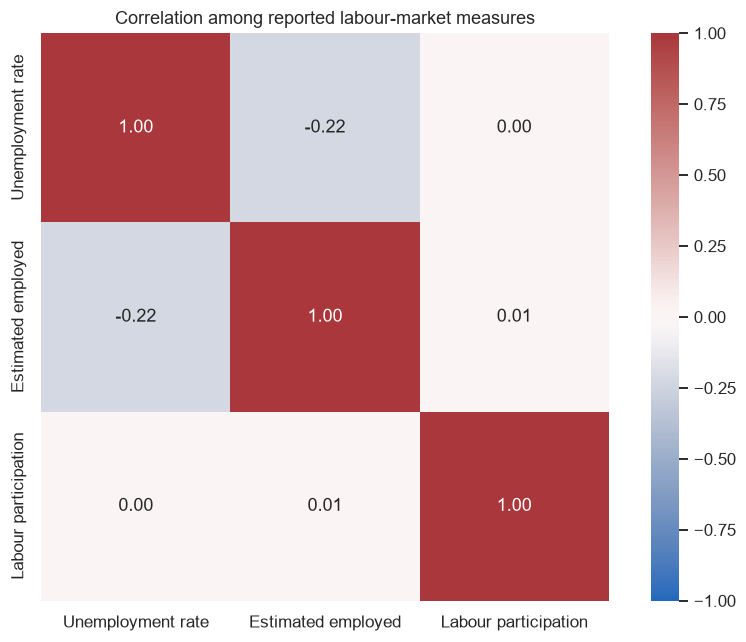

In [10]:
correlation_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)",
]
correlation_data = df[correlation_columns].dropna()
correlation_matrix = correlation_data.corr()
print(f"Rows used for pairwise correlation: {len(correlation_data):,}")
display(correlation_matrix.round(3))

labels = ["Unemployment rate", "Estimated employed", "Labour participation"]
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="vlag", center=0, vmin=-1, vmax=1,
            xticklabels=labels, yticklabels=labels, fmt=".2f", square=True)
plt.title("Correlation among reported labour-market measures")
plt.tight_layout()
plt.show()

**Interpretation:** values nearer +1 indicate positive linear association in these records; values nearer -1 indicate negative linear association. Neither the sign nor size establishes a causal mechanism, and the employment count's scale/population relationship is an important caveat.

## 11. Pre-COVID and COVID-era descriptive comparison

For a transparent split, **pre-COVID** means dates before **2020-03-01** and **COVID-era** means dates on or after that date. March 2020 observations are therefore in the latter group. The split is a descriptive convention, not a causal design; the source's time coverage is limited.

,region_area_month_rows,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Period,,,,
Pre-COVID (< 2020-03-01),536,9.51,7466027.87,43.89
COVID-era (>= 2020-03-01),204,17.77,6517203.34,39.33


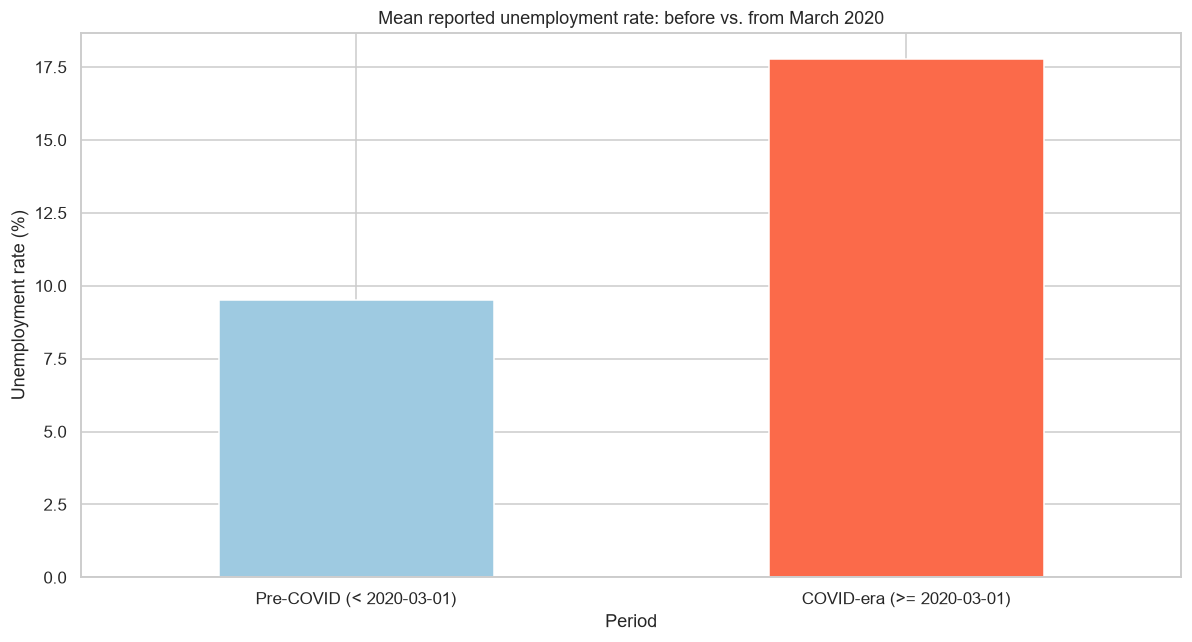

Descriptive difference (COVID-era minus pre-COVID): +8.26 percentage points
Cutoff: 2020-03-01 | Observations by period: {'Pre-COVID (< 2020-03-01)': 536, 'COVID-era (>= 2020-03-01)': 204}


In [11]:
covid_cutoff = pd.Timestamp("2020-03-01")
df["Period"] = df["Date"].ge(covid_cutoff).map({False: "Pre-COVID (< 2020-03-01)", True: "COVID-era (>= 2020-03-01)"})

period_summary = df.groupby("Period")[measurement_columns].mean().reindex(
    ["Pre-COVID (< 2020-03-01)", "COVID-era (>= 2020-03-01)"]
)
period_counts = df.groupby("Period").size().reindex(period_summary.index).rename("region_area_month_rows")
display(pd.concat([period_counts, period_summary], axis=1).round(2))

rate_by_period = df.groupby("Period")["Estimated Unemployment Rate (%)"].mean().reindex(period_summary.index)
ax = rate_by_period.plot(kind="bar", color=["#9ecae1", "#fb6a4a"], rot=0)
ax.set(title="Mean reported unemployment rate: before vs. from March 2020", xlabel="Period", ylabel="Unemployment rate (%)")
plt.tight_layout()
plt.show()

difference = rate_by_period.iloc[1] - rate_by_period.iloc[0]
print(f"Descriptive difference (COVID-era minus pre-COVID): {difference:+.2f} percentage points")
print(f"Cutoff: {covid_cutoff.date()} | Observations by period: {period_counts.to_dict()}")

**Interpretation:** compare the two period means and record their difference in percentage points. This comparison does not control for seasonality, region composition, other economic changes, or measurement changes; it must not be described as the pandemic's causal effect.

## 12. Reproducible summary of findings

The statements below are generated from the cleaned data on execution, so they reflect the actual downloaded file rather than hand-entered numbers.

In [12]:
highest_region = region_means.idxmax()
lowest_region = region_means.idxmin()
peak_month = monthly_mean.idxmax()
trough_month = monthly_mean.idxmin()
print(
    f"The cleaned file contains {len(df):,} region-area observations across "
    f"{df['Region'].nunique()} regions, from {df['Date'].min():%B %Y} through {df['Date'].max():%B %Y}."
)
print(
    f"The highest and lowest unweighted region means are {highest_region} "
    f"({region_means.loc[highest_region]:.2f}%) and {lowest_region} "
    f"({region_means.loc[lowest_region]:.2f}%), respectively."
)
print(
    f"The monthly cross-region mean peaks in {peak_month:%B %Y} "
    f"({monthly_mean.loc[peak_month]:.2f}%) and is lowest in {trough_month:%B %Y} "
    f"({monthly_mean.loc[trough_month]:.2f}%)."
)
print(
    f"The descriptive unemployment-rate difference for the chosen split is "
    f"{difference:+.2f} percentage points (COVID-era minus pre-COVID)."
)
print("These summaries describe this dataset only; they do not establish causes or represent population-weighted estimates.")

The cleaned file contains 740 region-area observations across 28 regions, from May 2019 through June 2020.
The highest and lowest unweighted region means are Tripura (28.35%) and Meghalaya (4.80%), respectively.
The monthly cross-region mean peaks in May 2020 (25.62%) and is lowest in May 2019 (9.03%).
The descriptive unemployment-rate difference for the chosen split is +8.26 percentage points (COVID-era minus pre-COVID).
These summaries describe this dataset only; they do not establish causes or represent population-weighted estimates.
